# 05 — Vyhodnocení a srovnání

Závěrečný krok studie. Všechny tři modely se porovnají na **stejném, dosud
nedotčeném testovacím setu**.

Teorie k metrikám: [`devnotes/teorie/03_loss_metriky_a_trenink.md`](../devnotes/teorie/03_loss_metriky_a_trenink.md)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from _common import *
import cv2, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
print("repo:", REPO_ROOT)

repo: C:\GitHub\USU-zapocet


## 1. Jak je srovnání zařízené, aby bylo férové

Všechny tři modely produkují **identický typ artefaktu**: PNG masku s hodnotami
0–6 o rozměru původního snímku.

| model | čím vzniká |
|---|---|
| U-Net | `training/predict.py --model unet` |
| UNETR | `training/predict.py --model unetr` |
| TotalSegmentator2D | `scripts/ts2d_inference.py` |

Evaluační skript pak **vůbec neví, který model masku vyrobil** — porovnává jen
PNG proti PNG. Do srovnání se tak nemůže vloudit nespravedlnost tím, že by se
jeden model vyhodnocoval jinak než druhý.

## 2. Generování predikcí

Vyžaduje natrénované checkpointy v `training_outputs/checkpoints/`. Když se
model trénoval jinde, stačí sem zkopírovat `.pth` soubor — nic jiného se
přenášet nemusí.

In [2]:
ckpt_dir = OUTPUTS_DIR / "checkpoints"
found = sorted(ckpt_dir.glob("*.pth")) if ckpt_dir.exists() else []
print("nalezené checkpointy:")
for c in found:
    print(f"  {c.name}  ({c.stat().st_size/1e6:.0f} MB)")
if not found:
    print("  žádné — nejdřív trénink (notebooky 02 a 03)")

nalezené checkpointy:
  smoke-unet-last.pth  (20 MB)
  smoke-unetr-best.pth  (87 MB)
  smoke-unetr-last.pth  (87 MB)
  unet-atlas-v1-best.pth  (20 MB)
  unet-atlas-v1-last.pth  (20 MB)
  unetr-atlas-v1-best.pth  (87 MB)
  unetr-atlas-v1-last.pth  (87 MB)


In [3]:
# Predikce už jsou vygenerované ostrým během. Kdyby bylo potřeba je vyrobit
# znovu (jiný checkpoint, jiný split), stačí odkomentovat — každý běh trvá
# desítky sekund až minuty:
# run_script("training/predict.py", "--model", "unet",  "--split", "test")
# run_script("training/predict.py", "--model", "unetr", "--split", "test")
# run_script("scripts/ts2d_inference.py", "--split", "test")

pred_dir = OUTPUTS_DIR / "predictions"
if pred_dir.exists():
    for d in sorted(pred_dir.iterdir()):
        if d.is_dir():
            print(f"{d.name:10s}: {len(list(d.glob('*.png')))} masek")

ts2d      : 992 masek
unet      : 992 masek
unetr     : 992 masek


## 3. Metriky

Počítají se dvě: **Dice** a **IoU**. Obě měří překryv predikce a skutečnosti,
ale jinak váží — IoU je přísnější, Dice shovívavější k drobným odchylkám na
hranici. Proto se uvádějí obě.

$$\text{Dice} = \frac{2|A \cap B|}{|A| + |B|} \qquad
  \text{IoU} = \frac{|A \cap B|}{|A \cup B|}$$

**Pozadí se do průměru nepočítá.** Obratle zabírají kolem 3 % plochy, takže
model predikující výhradně pozadí by s pozadím v průměru vypadal skvěle a
neznamenalo by to nic.

Když třída není ani v ground truth, ani v predikci, není co měřit — zapíše se
`NaN` a průměruje se přes `nanmean`. Když ale třída v ground truth **je** a
model ji nenajde, je to skutečná chyba a počítá se jako Dice 0.

In [4]:
run_script("scripts/evaluate_models.py", "--split", "test", "--figures", "4")

$ py -3 -u scripts/evaluate_models.py --split test --figures 4



[eval] split=test, snimku=992, modelu=3: ts2d, unet, unetr


[eval] ts2d ...


[eval] unet ...


[eval] unetr ...


...

------------------------------------------------------------------------


Dice/IoU = prumer pres tridy C2-C7 BEZ pozadi. Sloupce vpravo = Dice po tridach.


[eval] vystup: C:\GitHub\USU-zapocet\training_outputs\evaluation



[navratovy kod: 0]


0

## 4. Výsledky

In [5]:
summary_path = OUTPUTS_DIR / "evaluation" / "summary_test.csv"
if summary_path.exists():
    df = pd.read_csv(summary_path, index_col="model")
    display(df[["mean_dice", "mean_iou"]].style.format("{:.4f}")
              .background_gradient(cmap="RdYlGn", vmin=0, vmax=1))
else:
    print("Nejdřív spusť evaluaci.")

,mean_dice,mean_iou
model,,
unet,0.9412,0.8942
unetr,0.9229,0.8658
ts2d,0.0004,0.0003


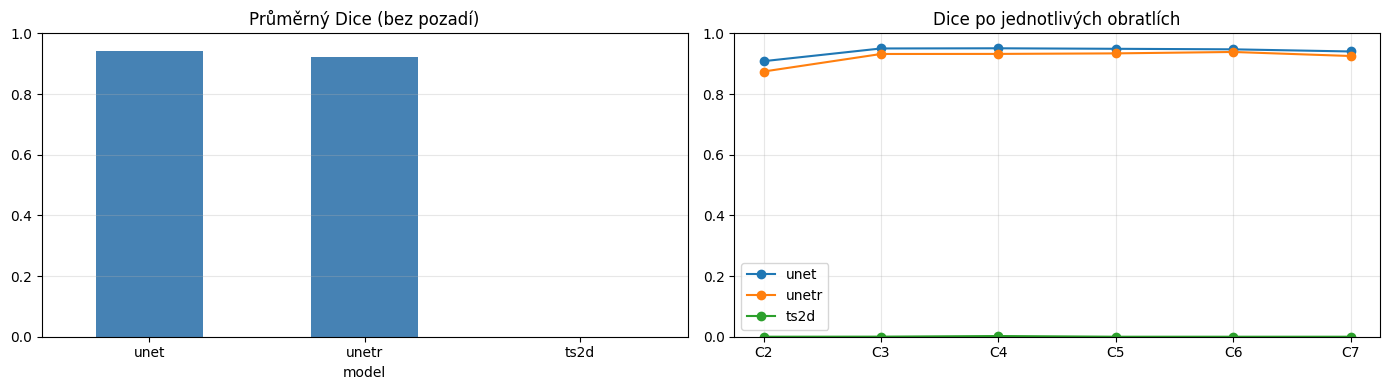

In [6]:
if summary_path.exists():
    df = pd.read_csv(summary_path, index_col="model")
    classes = ["C2", "C3", "C4", "C5", "C6", "C7"]

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    df["mean_dice"].plot.bar(ax=ax[0], color="steelblue", rot=0)
    ax[0].set_title("Průměrný Dice (bez pozadí)"); ax[0].set_ylim(0, 1); ax[0].grid(axis="y", alpha=.3)

    for m in df.index:
        ax[1].plot(classes, [df.loc[m, f"dice_{c}"] for c in classes], "o-", label=m)
    ax[1].set_title("Dice po jednotlivých obratlích"); ax[1].set_ylim(0, 1)
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

### Rozptyl mezi snímky

Průměr sám o sobě zakrývá, jestli model funguje stabilně, nebo je na některých
snímcích výborný a na jiných úplně mimo.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10688\1812409870.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([per_img[per_img["model"] == m]["dice"].dropna() for m in models], labels=models)


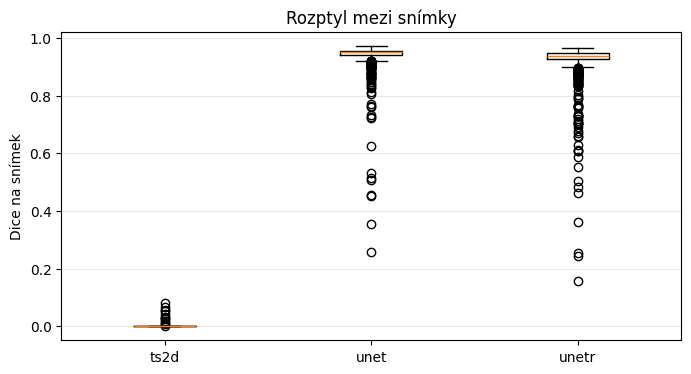

In [7]:
per_image_path = OUTPUTS_DIR / "evaluation" / "per_image_test.csv"
if per_image_path.exists():
    pi = pd.read_csv(per_image_path)
    per_img = pi.groupby(["model", "stem"])["dice"].mean().reset_index()
    models = per_img["model"].unique()

    plt.figure(figsize=(8, 4))
    plt.boxplot([per_img[per_img["model"] == m]["dice"].dropna() for m in models], labels=models)
    plt.ylabel("Dice na snímek"); plt.title("Rozptyl mezi snímky"); plt.grid(axis="y", alpha=.3)
    plt.show()

## 5. Vizuální srovnání

Čísla neukážou všechno. Vizuální kontrola odhalí věci, které se v průměru
ztratí — třeba že model najde obratle správně, ale posunuté o jednu pozici.

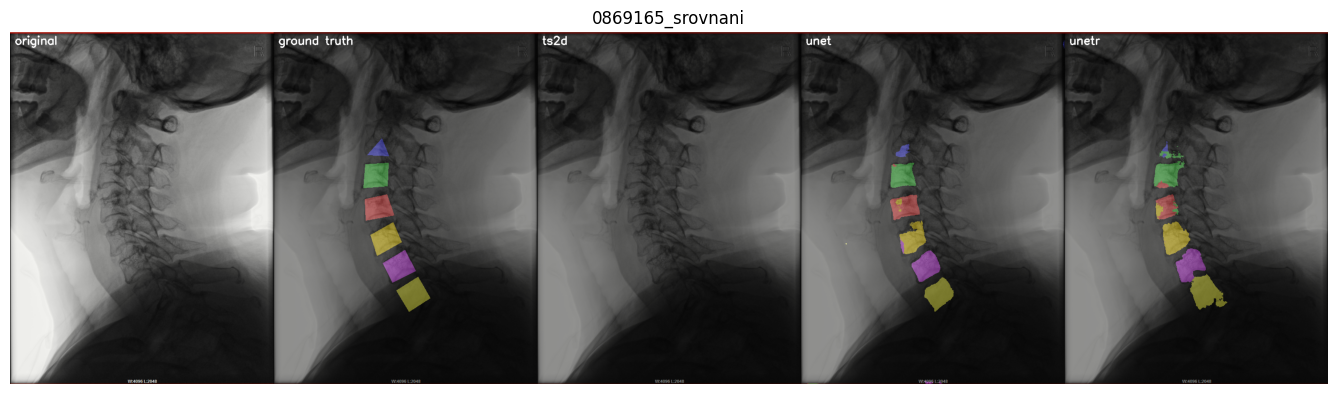

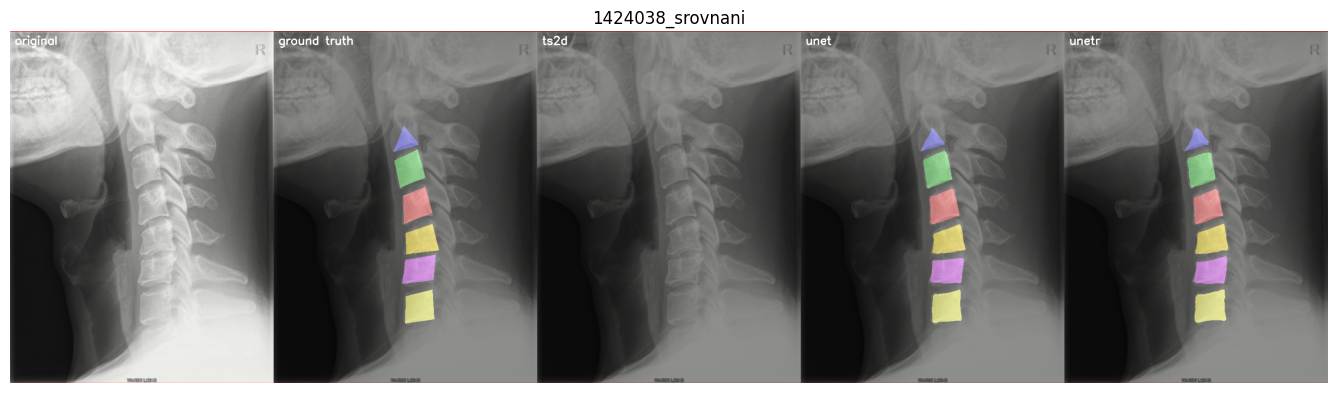

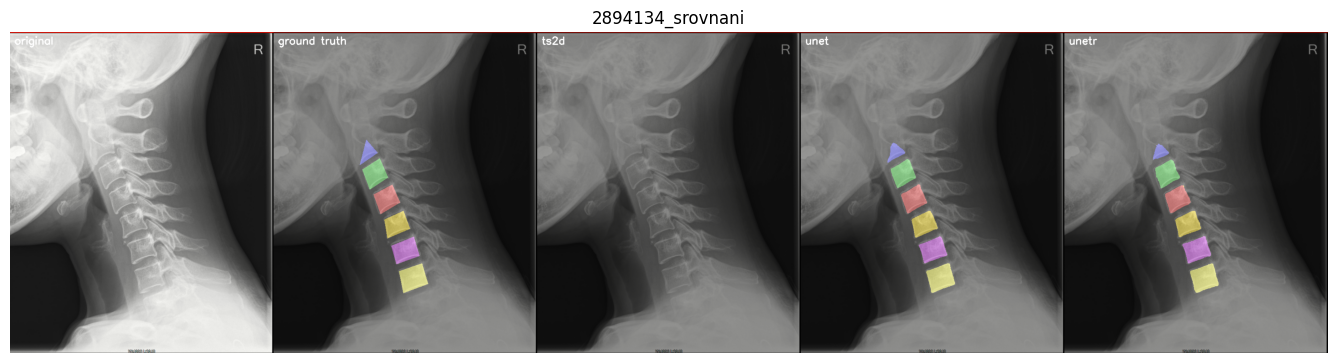

In [8]:
fig_dir = OUTPUTS_DIR / "evaluation" / "srovnani"
figs = sorted(fig_dir.glob("*.png")) if fig_dir.exists() else []
for f in figs[:3]:
    im = cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(17, 7)); plt.imshow(im); plt.axis("off")
    plt.title(f.stem); plt.show()
if not figs:
    print("Nejdřív spusť evaluaci.")

## 6. Závěr

### Naměřené výsledky (testovací set, 992 snímků)

| Model | Dice | IoU |
|---|---:|---:|
| **U-Net** | **0,9412** | **0,8942** |
| UNETR (ViT-Tiny) | 0,9229 | 0,8658 |
| TotalSegmentator2D | 0,0004 | 0,0003 |

### Vyhodnocení hypotézy

Hypotéza z [`devnotes/plan.md`](../devnotes/plan.md) měla dvě části a
**potvrdila se jen jedna**:

1. *„UNETR dosáhne srovnatelných nebo lepších výsledků než U-Net"* —
   **zčásti**. Výsledky jsou srovnatelné (rozdíl 0,018 Dice), ale UNETR
   U-Net nepřekonal. Očekávaná výhoda globálního kontextu z attention se
   neprojevila; úloha je totiž silně lokální — obratle jsou kompaktní útvary
   a konvoluční induktivní bias na ně sedí lépe.
2. *„Oba doménově trénované modely překonají TotalSegmentator2D"* —
   **potvrzeno drtivě** (0,94 a 0,92 proti 0,0004).

### Co stojí za pozornost

**Rozdíl mezi U-Netem a UNETR je konzistentní napříč všemi třídami**
(~0,02 u každého obratle). Není to tedy tak, že by UNETR selhával na něčem
konkrétním — je systematicky o kousek horší. To je čistší zjištění, než kdyby
měl výpadek na jedné třídě.

**C2 je pro oba modely nejtěžší** (0,908 a 0,874 proti 0,93–0,95 u ostatních).
Souvisí to s anotací: C2 má jen tři landmarky místo čtyř, takže jeho maska je
trojúhelníková aproximace. Je to strop daný daty, ne slabina modelů.

**Cesta UNETR z 0,106 na 0,923** je nejsilnější poznatek celé práce. Ve
zkušebním běhu vypadal jako selhání a uvažovalo se o jeho nahrazení. Rozhodly
dvě věci, obě doložené měřením (viz notebook 03 a
[`devnotes/STAV_PROJEKTU.md`](../devnotes/STAV_PROJEKTU.md) §8.10):
zmenšení Vision Transformeru ze 116 M na 8,4 M parametrů a plný dataset místo
400 snímků. Závěr tedy nezní „transformer na tuto úlohu nestačí", ale
**„transformer je konkurenceschopný, pokud se naškáluje na objem dostupných dat"**.

**Poměr cena/výkon** přesto vychází ve prospěch U-Netu: má 5× méně parametrů,
trénuje se 2× rychleji (3,5 vs 7,0 min/epocha) a je o 0,018 Dice lepší.

### Omezení práce

Je poctivé uvést:

- Maska je **čtyřúhelníková aproximace** obratle, ne přesný obrys — strop pro
  dosažitelný Dice, stejný pro všechny modely.
- **Jeden pevný split** místo křížové validace (výpočetní rozpočet), takže
  výsledky jsou zatížené variabilitou konkrétního rozdělení.
- **Výřezy 256 px** místo 512 px kvůli kvadratické ceně attention.
- U-Net byl na stropě zhruba od 15. epochy, zatímco UNETR stoupal až do konce —
  **při delším tréninku by se rozdíl mohl dál zmenšit**.
- TotalSegmentator2D nebyl na tuto doménu trénován; jeho výsledek nevypovídá
  o kvalitě nástroje, jen o přenositelnosti mimo trénovací doménu.